Although the notes in here should help guide you through the codes, if you have no experience with Python, it would be worth familiarising yourself with the following to avoid confusion:



*   Data structures (E.g. lists, dictionaries, dataframes)
*   Slicing data
*   Installing packages
*   Managing environment paths (Related to the previous point)
*   Functions
*   For loops

Please note that due to differences in packages (e.g. ggplot vs matplotlib), you may not be able to replicate the same outputs as in R.


Download week1_answers.csv, week1_boris.csv, week1_liz.csv and week1_rishi.csv from github onto your local machine.

On Colab, create a folder called Week1 in the session and upload the files into that folder.

You can create a new folder by

*   Clicking on the folder icon on the left margin.
*   Then, right click and select New Folder.
*   Upload the 3 CSV files into the folder

Note that when you log out of this session, the folder and files will disappear, and you will have to re-upload the data.

Lets begin!

In [ ]:
# Ensure that pingouin has been installed using pip install pingouin. You will need this later for the Chronbach's alpha.
# Note: you may be prompted to restart the runtime session after the instalation has finished.
# Choose restart if prompted

%pip install pingouin

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.9/198.9 kB 1.6 MB/s eta 0:00:00


In [ ]:
!pip install adjustText

In [ ]:
import pandas as pd
import numpy as np
import os

# Analytics
import pingouin as pg
from scipy.stats import pearsonr
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Lasso

# NLP
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from nltk.util import ngrams
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords
import string
import re

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# check location if using local machine
print(os.getcwd())

# Change accordingly when running on your local machine
os.chdir('/content/Week1')
print(os.getcwd()) # check the folder is created in the right place

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


/content
/content/Week1


In [ ]:
# Read CSV into dataframe
week1_boris = pd.read_csv('week1_boris.csv', encoding = 'latin-1')
week1_rishi = pd.read_csv('week1_rishi.csv', encoding = 'latin-1')
week1_liz = pd.read_csv('week1_liz.csv', encoding = 'latin-1')

# be careful of the encoding on certain files

In [ ]:
# Check column names
print(list(week1_boris))
print(list(week1_rishi))
print(list(week1_liz))

# check for any blank cells
print(np.where(pd.isnull(week1_boris)))  # if any empty, arrays should be blank
print(np.where(pd.isnull(week1_rishi)))
print(np.where(pd.isnull(week1_liz)))

['review_id', 'text', 'stars_boris', 'price_boris', 'gender_boris']
['review_id', 'text', 'stars_rishi', 'price_rishi', 'gender_rishi']
['review_id', 'text', 'stars_liz', 'price_liz', 'gender_liz']
(array([], dtype=int64), array([], dtype=int64))
(array([], dtype=int64), array([], dtype=int64))
(array([], dtype=int64), array([], dtype=int64))


In [ ]:
# Left join 3 dataframes on specific column names in one go!
# Note, there are different methods for joining tables (e.g. pd.concat())
# Generally, 'merge' is the safer option
week1 = pd.merge(pd.merge(week1_boris, week1_rishi,how='left', on=['review_id', 'text']), week1_liz, how='left', on=['review_id', 'text'])

# Note to avoid duplicate 'text' columns, include the column name in the join statement
print(list(week1))

# Fast way of checking the first 5 rows
print(week1.head())

['review_id', 'text', 'stars_boris', 'price_boris', 'gender_boris', 'stars_rishi', 'price_rishi', 'gender_rishi', 'stars_liz', 'price_liz', 'gender_liz']
                review_id                                               text  \
0  dMI-y2eHopS90LBhngHhpA  Yeah, I know there's a lot of people here. Doe...   
1  46T_5Ac7sEta4u3w5BHtPw  The location of this store is great and I like...   
2  bSmRF1xJA11Cc0ygpW0bNg  Second time here and this time is with my sist...   
3  vLQcoBfwGR0uV2G8rmWFZQ  Less than impressed. The Chinese spiced pork w...   
4  21rH9QQ-s-2X5TAbuumeNg  This probably one of the worst places I have h...   

   stars_boris  price_boris gender_boris  stars_rishi  price_rishi  \
0            4            1         male            4            1   
1            2            2         male            2            1   
2            4            2         male            2            1   
3            2            1         male            4            2   
4            2 

Let's check the consistency of star ratings from all the datasets

We need to calculate Pearson's correlation

**Check that you have from scipy.stats import pearsonr**

The Pearson’s correlation coefficient is calculated as the covariance of
the two variables divided by the product of the standard deviation of each data sample.

It is the normalization of the covariance between the two variables to give an interpretable score.

Pearson's correlation coefficient = covariance(X, Y) / (stdv(X) * stdv(Y))

In [ ]:
# Correlation on ONLY 2 variables:
corr, _ = pearsonr(week1['stars_boris'], week1['stars_rishi'])
print(round(corr, 3))

# Alternatively you could subset the dataframe and perform a correlation on the whole dataframe
# This will return a correlatio matrix
# The default correlation matrix method is pearson's
print(week1[['stars_boris', 'stars_rishi', 'stars_liz']].corr())

-0.125
              stars_boris  stars_rishi     stars_liz
stars_boris  1.000000e+00       -0.125 -1.040834e-16
stars_rishi -1.250000e-01        1.000  7.500000e-01
stars_liz   -1.040834e-16        0.750  1.000000e+00


In [ ]:
# Repeat for price and gender
print(week1[['price_boris', 'price_rishi', 'price_liz']].corr())

# For gender, use one hot encoding to convert categorical variables into binary
# pd.get_dummies will create binary variables for all categories (i.e. male and female).
# We only need one set of variables (e.g. male = 1 and female = 0).
# Use drop_first = True to get k-1 dummies out of k categorical levels by removing the first level
week1 = pd.get_dummies(week1, columns=['gender_boris', 'gender_rishi', 'gender_liz'], drop_first=True)

print(list(week1))

# Now we can do the correlation. Note that gender_boris is now called gender_boris_male
print(week1[['gender_boris_male', 'gender_rishi_male', 'gender_liz_male']].corr())

# since we know that 1 = male, we can change the column titles back to gender_boris, gender_rishi and gender_liz
# {} denote python dictionary structures which stores key value pairs
week1.rename(columns={
    'gender_boris_male': 'gender_boris',
    'gender_rishi_male': 'gender_rishi',
    'gender_liz_male': 'gender_liz'
}, inplace=True)

             price_boris  price_rishi  price_liz
price_boris        1.000       -0.125     -0.125
price_rishi       -0.125        1.000      0.875
price_liz         -0.125        0.875      1.000
['review_id', 'text', 'stars_boris', 'price_boris', 'stars_rishi', 'price_rishi', 'stars_liz', 'price_liz', 'gender_boris_male', 'gender_rishi_male', 'gender_liz_male']
                   gender_boris_male  gender_rishi_male  gender_liz_male
gender_boris_male       1.000000e+00      -6.938894e-18            0.125
gender_rishi_male      -6.938894e-18       1.000000e+00            0.250
gender_liz_male         1.250000e-01       2.500000e-01            1.000


Correlations give us "pairwise" summary statistics. What if we want to summarize more than two columns? We calculate the Cronbach's alpha

Ensure that pingouin has been installed using pip install pingouin - you should have done this at the beginning.

In [ ]:
print(pg.cronbach_alpha(week1[['stars_boris', 'stars_rishi', 'stars_liz']]))

# the output should look something like this: (0.4411764705882352, array([-0.005,  0.709])) where
# the alpha is the first value in the list and the array gives the confidence intervals

(0.4411764705882352, array([-0.005,  0.709]))


Next, reshape the data so we can merge with the actual answers

In [ ]:
# Converting to long format

# check dimensions of current dataframe
print(week1.shape)

week1_long = week1.melt(id_vars=['review_id', 'text'], var_name='question', value_name='guess')

print(list(week1_long))

# split questions into 2 seperate columns for metric and annotator

week1_long[['metric', 'annotator']] = week1_long['question'].str.split('_', expand=True)
print(week1_long.head())
print(list(week1_long))


# change the order so 'guess' goes last and 'question' is dropped

keep = ['review_id', 'text', 'metric', 'annotator', 'guess']
week1_long = week1_long[keep]

print(week1_long.head())
print(list(week1_long))

# check dimensions of the dataframe again - we should have only 5 columns
print(week1_long.shape)

(32, 11)
['review_id', 'text', 'question', 'guess']
                review_id                                               text  \
0  dMI-y2eHopS90LBhngHhpA  Yeah, I know there's a lot of people here. Doe...   
1  46T_5Ac7sEta4u3w5BHtPw  The location of this store is great and I like...   
2  bSmRF1xJA11Cc0ygpW0bNg  Second time here and this time is with my sist...   
3  vLQcoBfwGR0uV2G8rmWFZQ  Less than impressed. The Chinese spiced pork w...   
4  21rH9QQ-s-2X5TAbuumeNg  This probably one of the worst places I have h...   

      question  guess metric annotator  
0  stars_boris      4  stars     boris  
1  stars_boris      2  stars     boris  
2  stars_boris      4  stars     boris  
3  stars_boris      2  stars     boris  
4  stars_boris      2  stars     boris  
['review_id', 'text', 'question', 'guess', 'metric', 'annotator']
                review_id                                               text  \
0  dMI-y2eHopS90LBhngHhpA  Yeah, I know there's a lot of people here. Doe..

In [ ]:
# Let's bring in our correct answers
week1_answers = pd.read_csv('week1_answers.csv')

print(list(week1_answers))
print(list(week1_answers['gender']))


['review_id', 'text', 'stars', 'price', 'gender']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
week1_answers_long = week1_answers.melt(id_vars=['review_id', 'text'], var_name='metric', value_name='answers')
print(list(week1_answers_long))

# As before, let's perform a left_join
week1_all = pd.merge(week1_long, week1_answers_long, how='left', on=['review_id', 'metric'])
print(list(week1_all))

['review_id', 'text', 'metric', 'answers']
['review_id', 'text_x', 'metric', 'annotator', 'guess', 'text_y', 'answers']


How many of the actual answers did we guess correctly?

Calculating accuracy here is easy: does the guess equal the answer?

Accuracy for classification means how many values in the 'predicted' column are equal to those in the 'actual' column. In this case we compare matches between 'guess' and 'answers'

In machine learning, calculating accuracy scores is pretty straightforward using **sklearn**

In [ ]:
accuracy = accuracy_score(week1_all['guess'], week1_all['answers'])

print(round(accuracy, 2))

0.53


In [ ]:
# But we want to calculate accuracy separately for each metric/annotator

metric_names = pd.unique(week1_all['metric'])
annotator_names = pd.unique(week1_all['annotator'])

# One common aproach in Python would be to subset the dataframe
# based on metric/annotator name and then
# calculate the scores for each subset of the dataframe
for metric in metric_names:

    week1_sub = week1_all[week1_all['metric'] == metric]
    accuracy = accuracy_score(week1_sub['guess'], week1_sub['answers'])
    print(round(accuracy, 2))

0.54
0.58
0.46


However, because we want to repeat this for annotators as well, it would be more efficient to write a general function and then apply that function to the data and field (columns) we want.

Run the below function to read the function in, then call the function afterwards with the desired parameters.

In [ ]:
def acc_subdomain(df, field, classes):
    '''
    Takes in a field (metric_names or annotator_names
    outputs accuracy scores for all classes in that field in a list
    '''

    results = []

    for c in classes:
        df_sub = df[df[field] == c]
        accuracy = accuracy_score(df_sub['guess'], df_sub['answers'])
        results.append(round(accuracy, 2))

    results = pd.DataFrame([classes, results], index=['class', 'accuracy']).T

    return results

In [ ]:
# Use the function to get accuracy scores for all classes of the metrics field:
acc_metrics = acc_subdomain(week1_all, 'metric', metric_names)
print(acc_metrics)

# Repeating for the annotators field
acc_annotator = acc_subdomain(week1_all, 'annotator', annotator_names)
print(acc_annotator)

    class accuracy
0   stars     0.54
1   price     0.58
2  gender     0.46
   class accuracy
0  boris      0.5
1  rishi     0.54
2    liz     0.54


Maybe we want standard errors? our formula for binary data is p*(1-p)/sqrt(n)

we modify our function to...

In [ ]:
def acc_subdomain(df, field, classes):
    '''
    Takes in a field (metric_names or annotator_names)
    outputs:
        accuracy scores for all classes in that field in a list
        standardised scores
    '''

    acc_all = []
    se_all = []

    for c in classes:
        df_sub = df[df[field] == c]
        accuracy = accuracy_score(df_sub['guess'], df_sub['answers'])
        se = np.sqrt(accuracy * (1 - accuracy) / df_sub.shape[0])
        acc_all.append(round(accuracy, 2))
        se_all.append(round(se, 2))

    results = pd.DataFrame([classes, acc_all, se_all], index=['class', 'accuracy', 'se']).T

    return results

In [ ]:
acc_metrics = acc_subdomain(week1_all, 'metric', metric_names)
print(acc_metrics)

# Repeating for the annotators field
acc_annotator = acc_subdomain(week1_all, 'annotator', annotator_names)
print(acc_annotator)

    class accuracy    se
0   stars     0.54  0.05
1   price     0.58  0.05
2  gender     0.46  0.05
   class accuracy    se
0  boris      0.5  0.05
1  rishi     0.54  0.05
2    liz     0.54  0.05


Tables are fun, but graphs are even more fun

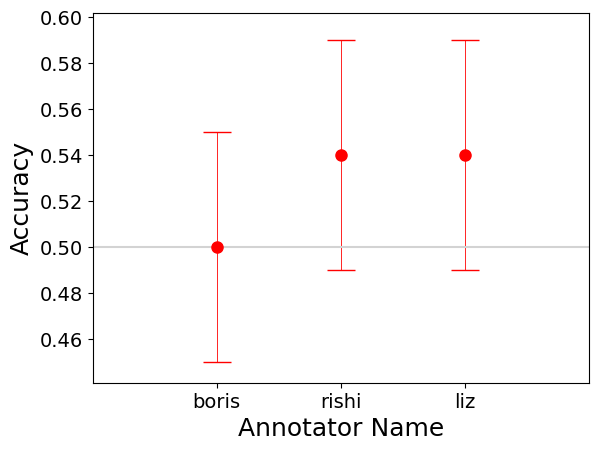

In [ ]:
# Choose your variables
y = acc_annotator['accuracy']
err = acc_annotator['se']
x = acc_annotator['class']

fig = plt.figure()

# you can add elements to the chart one line at a time
# each point is plotted seperately as matplotlib will otherwise treat them as the same series
# elinewidth = thickness of line, capsize = the top and bottom horizontal lines on the error bars

# NOTE this notebook is a little funny and may throw an assertion error
# if you want to overlay multiple series (e.g. with different colours) on top of each other

# On your local machine, this is not an issue at all.

# To get the code to run on Colab, this use this line
plt.errorbar(x, y, yerr=err, fmt="o", color="r", elinewidth=.6, markersize=8, capsize=10)

# If running on your local machine and you want different colours for each marker, use these commands instead
# plt.errorbar(x[0], y[0], yerr=err[0], fmt="o", color="r", elinewidth=.6, markersize=8, capsize=10)
# plt.errorbar(x[1], y[1], yerr=err[1], fmt="o", color="b", elinewidth=.6, markersize=8, capsize=10)

# add horizontal line
plt.axhline(y=0.5, color='lightgrey', linestyle='-')

# add axis labels
plt.xlabel('Annotator Name', fontsize=18)
plt.ylabel('Accuracy', fontsize=18)

# Makes the margins a bit wider (useful when there's only 2 points)
plt.margins(0.5, tight=True)

# set the height of the yaxis to be proportional to the data
plt.ylim(top=((max(y) + max(err))) * 1.02,
         bottom=((min(y) - min(err))) * 0.98)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

Let's do this all again, but for all the metrics as well as the annotators. First, we need to reformat the data by amending the function to take in multiple parameters

In [ ]:
def acc_subdomain2(df, metric, annotator, metric_names, annotator_names):
    '''
    Takes in a field (metric_names or annotator_names)
    outputs:
        accuracy scores for all classes in that field in a list
        standardised scores
    '''

    acc_all = []
    se_all = []
    metric_name = []
    annotator_name = []

    for a in annotator_names:
        for m in metric_names:
            df_sub = df[(df[annotator] == a) & (df[metric] == m)]
            accuracy = accuracy_score(df_sub['guess'], df_sub['answers'])
            se = np.sqrt(accuracy * (1 - accuracy) / df_sub.shape[0])
            acc_all.append(round(accuracy, 2))
            se_all.append(round(se, 2))
            metric_name.append(m)
            annotator_name.append(a)

    results = pd.DataFrame([annotator_name, metric_name, acc_all, se_all], index=['annotator', 'metric', 'accuracy', 'se']).T

    return results

In [ ]:
# call the function with our new parameters
acc_all = acc_subdomain2(week1_all, 'metric', 'annotator', metric_names, annotator_names)
print(acc_all)

  annotator  metric accuracy    se
0     boris   stars     0.56  0.09
1     boris   price     0.56  0.09
2     boris  gender     0.38  0.09
3     rishi   stars     0.56  0.09
4     rishi   price     0.56  0.09
5     rishi  gender      0.5  0.09
6       liz   stars      0.5  0.09
7       liz   price     0.62  0.09
8       liz  gender      0.5  0.09


Lets chart them up

NOTE if you wish to run this on your local machine and you want different colours for each series, make sure you add each series independently.

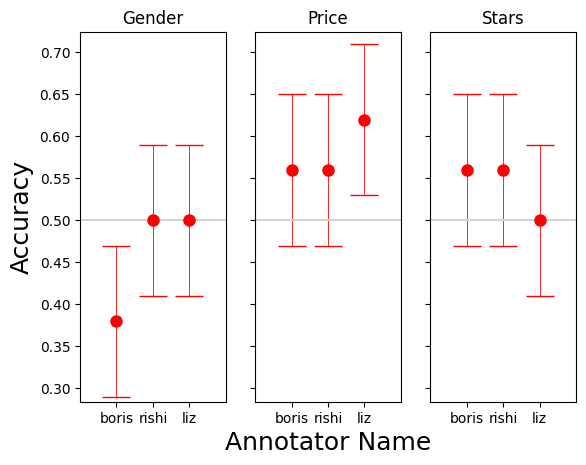

In [ ]:
# First, specify the layout - 1 row by 3 charts where they share the y and x axes
fig, axs = plt.subplots(1, 3, sharex=True, sharey=True)

# Define the variables
# subset the data for each metric starting with gender
acc_all_0 = acc_all[acc_all['metric'] == 'gender']

# x is the unique annotators
x = pd.unique(acc_all_0['annotator'])
# y = accuracy scores for any gender metrics for both annotators
y = acc_all_0['accuracy']
# y = standard errors for any gender metrics for both annotators
err = acc_all_0['se']

# Now the below looks a bit more familiar
axs[0].errorbar(x, y, yerr=err, fmt="o", color="r", elinewidth=.6, markersize=8, capsize=10)

# axs[0].errorbar(x[0], y.iloc[0], yerr=err.iloc[0], fmt="o", color="r", elinewidth=.6, markersize=8, capsize=10)
# axs[0].errorbar(x[1], y.iloc[1], yerr=err.iloc[1], fmt="o", color="b", elinewidth=.6, markersize=8, capsize=10)

axs[0].axhline(y=0.5, color='lightgrey', linestyle='-')
axs[0].margins(0.5, tight=True)

axs[0].set_title("Gender", fontsize=12)

# repeat the above for each metric...one could also write a forloop to loop over
# metrics data
acc_all_1 = acc_all[acc_all['metric'] == 'price']
y = acc_all_1['accuracy']
err = acc_all_1['se']

axs[1].errorbar(x, y, yerr=err, fmt="o", color="r", elinewidth=.6, markersize=8, capsize=10)

# axs[1].errorbar(x[0], y.iloc[0], yerr=err.iloc[0], fmt="o", color="r", elinewidth=.6, markersize=8, capsize=10)
# axs[1].errorbar(x[1], y.iloc[1], yerr=err.iloc[1], fmt="o", color="b", elinewidth=.6, markersize=8, capsize=10)

axs[1].axhline(y=0.5, color='lightgrey', linestyle='-')
axs[1].margins(0.5, tight=True)

axs[1].set_title("Price", fontsize=12)

acc_all_2 = acc_all[acc_all['metric'] == 'stars']
y = acc_all_2['accuracy']
err = acc_all_2['se']

axs[2].errorbar(x, y, yerr=err, fmt="o", color="r", elinewidth=.6, markersize=8, capsize=10)

# axs[2].errorbar(x[0], y.iloc[0], yerr=err.iloc[0], fmt="o", color="r", elinewidth=.6, markersize=8, capsize=10)
# axs[2].errorbar(x[1], y.iloc[1], yerr=err.iloc[1], fmt="o", color="b", elinewidth=.6, markersize=8, capsize=10)

axs[2].axhline(y=0.5, color='lightgrey', linestyle='-')
axs[2].margins(0.5, tight=True)

axs[2].set_title("Stars", fontsize=12)

plt.ylim(top=((max(acc_all['accuracy']) + max(acc_all['se'])) * 1.02),
         bottom=((min(acc_all['accuracy']) - min(acc_all['se'])) * 0.98))

# Set common labels
axs[1].set_xlabel('Annotator Name', fontsize=18)
axs[0].set_ylabel('Accuracy', fontsize=18)

# save the chart
plt.savefig('accuracy_scores.png', dpi=300, bbox_inches='tight')

plt.show()

Notice how there were a lot of repetitions in the code above?

Shorten the code by using a for loop, making our code a bit neater

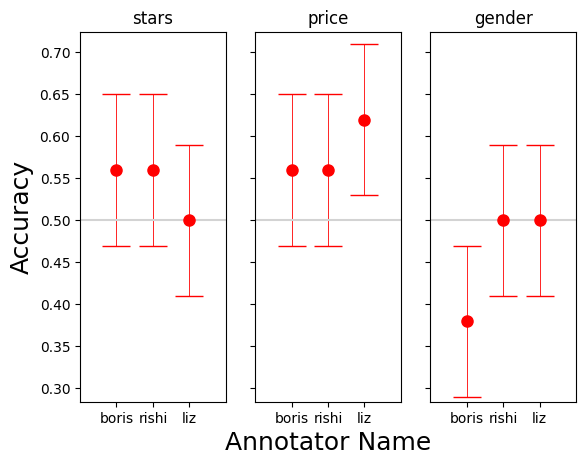

In [ ]:

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True)

# Remember that metric_names is the unique list of metrics names?
# axs[0], axs[1] and axs[2] have now been replaced by just axs[i]
# where i is the number of the element in metric_names

for i in list(range(len(metric_names))):
  acc_all_1 = acc_all[acc_all['metric'] == metric_names[i]]
  x = pd.unique(acc_all_1['annotator'])
  y = acc_all_1['accuracy']
  err = acc_all_1['se']

  axs[i].errorbar(x, y, yerr=err, fmt="o", color="r", elinewidth=.6, markersize=8, capsize=10)

  # This only works when using your local machine!
  # axs[i].errorbar(x[0], y.iloc[0], yerr=err.iloc[0], fmt="o", color="r", elinewidth=.6, markersize=8, capsize=10)
  # axs[i].errorbar(x[1], y.iloc[1], yerr=err.iloc[1], fmt="o", color="b", elinewidth=.6, markersize=8, capsize=10)

  axs[i].axhline(y=0.5, color='lightgrey', linestyle='-')
  axs[i].margins(0.5, tight=True)

  axs[i].set_title(metric_names[i], fontsize=12)

plt.ylim(top=((max(acc_all['accuracy']) + max(acc_all['se'])) * 1.02),
         bottom=((min(acc_all['accuracy']) - min(acc_all['se'])) * 0.98))

# Set common labels
axs[1].set_xlabel('Annotator Name', fontsize=18)
axs[0].set_ylabel('Accuracy', fontsize=18)

# save the chart
plt.savefig('accuracy_scores.png', dpi=300, bbox_inches='tight')

plt.show()

**Part 2 - NLP**

But first, a few tips on manipulating data strings and text data

In [ ]:
# joining strings in Python is simple - just add them

print('x' + 'y')

# to add spaces:
print('x' + ' ' + 'y')

xy
x y


In [ ]:
# len() counts anything in python. In this case, it counts
# the number of characters in a string
toolong="this string is good but it is too long"

print(len(toolong))

# To counts words, use split to generate list of words
print(toolong.split())

# then use len() again to ge the count
print(len(toolong.split()))

# List splicing can be used to...
# get first x elements in a string
print(toolong[0:20])
# first element to x elements form the end
print(toolong[0:-10])
# or just last x elements from the end
print(toolong[-20:])

38
['this', 'string', 'is', 'good', 'but', 'it', 'is', 'too', 'long']
9
this string is good 
this string is good but it i
d but it is too long


In [ ]:
# substituting one character for another

strings = ["abcx","defxx","ghiy"]

# Create a new list by looping through the elements of current list
# and applying replace() function
strings = [x.replace('x','y') for x in strings]
print(strings)

# To replace only the first instance only:
strings = ["abcx","defxx","ghiy"]
strings = [x.replace('x','y', 1) for x in strings]
print(strings)

['abcy', 'defyy', 'ghiy']
['abcy', 'defyx', 'ghiy']


In [ ]:
# Is a string contained within another string?
strings = ["teases","taxes","xylophone"]

# for one string, use simple logic evaluation to get boolean response
print('t' in 'teases')

# to search in whole list of strings, use list comprehension again
strings = ['t' in x for x in strings]
print(strings)

# to convert to lowercase, use lower() in list comprehension
strings = ["Teases","Taxes","Xylophone"]
print([x.lower() for x in strings])

# How many times does the letter 'a' appear in the list?
print(sum([x.count('a') for x in strings]))

True
[True, True, False]
['teases', 'taxes', 'xylophone']
2


In [ ]:
######### Simple bag of words
testDoc = ["This is a test sentence.",
            "I am providing another sentence to test this.",
            "This isn't a sentence",
            "This is a test document. It has 2 sentences"]

# First we need to split up the sentences into "tokens" - (usually words)
# an easy methog is to use the nltk package

docs = [word_tokenize(i) for i in testDoc]
print(docs)

[['This', 'is', 'a', 'test', 'sentence', '.'], ['I', 'am', 'providing', 'another', 'sentence', 'to', 'test', 'this', '.'], ['This', 'is', "n't", 'a', 'sentence'], ['This', 'is', 'a', 'test', 'document', '.', 'It', 'has', '2', 'sentences']]


In [ ]:
# We then count how often each token occurs in each document
# This produces a "document feature matrix" (or document term matrix)
# One row for each doc, one column for each feature

# Without tfidf, all words are given the same weight

docs = testDoc
vec = CountVectorizer()
X = vec.fit_transform(docs)
df = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
df

,am,another,document,has,is,isn,it,providing,sentence,sentences,test,this,to
0,0,0,0,0,1,0,0,0,1,0,1,1,0
1,1,1,0,0,0,0,0,1,1,0,1,1,1
2,0,0,0,0,0,1,0,0,1,0,0,1,0
3,0,0,1,1,1,0,1,0,0,1,1,1,0


In [ ]:
# We can also combine adjoining words into "bigrams"

docs = testDoc
for line in docs:
    token = nltk.word_tokenize(line)
    bigram = list(ngrams(token, 2)) # The '2' represents bigram
    print(bigram)

[('This', 'is'), ('is', 'a'), ('a', 'test'), ('test', 'sentence'), ('sentence', '.')]
[('I', 'am'), ('am', 'providing'), ('providing', 'another'), ('another', 'sentence'), ('sentence', 'to'), ('to', 'test'), ('test', 'this'), ('this', '.')]
[('This', 'is'), ('is', "n't"), ("n't", 'a'), ('a', 'sentence')]
[('This', 'is'), ('is', 'a'), ('a', 'test'), ('test', 'document'), ('document', '.'), ('.', 'It'), ('It', 'has'), ('has', '2'), ('2', 'sentences')]


In [ ]:
# we can stem words
snow_stemmer = SnowballStemmer(language='english')

docs = testDoc

docs = [[snow_stemmer.stem(word) for word in x.split(" ")] for x in docs]
print(docs)

[['this', 'is', 'a', 'test', 'sentence.'], ['i', 'am', 'provid', 'anoth', 'sentenc', 'to', 'test', 'this.'], ['this', "isn't", 'a', 'sentenc'], ['this', 'is', 'a', 'test', 'document.', 'it', 'has', '2', 'sentenc']]


In [ ]:
# remove punctuation by creating new list
# add element to list element is not a punctuation given by string.punctuation

# to see list of punctuations:
print(string.punctuation)

docs = testDoc
print(["".join( j for j in i if j not in string.punctuation) for i in  docs])

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['This is a test sentence', 'I am providing another sentence to test this', 'This isnt a sentence', 'This is a test document It has 2 sentences']


In [ ]:
# use regex module to replace all numbers with '' in list
docs = testDoc
pattern = r'[0-9]'
# Match all digits in the string and replace them with an empty string
print([re.sub(pattern, '', x) for x in docs])

['This is a test sentence.', 'I am providing another sentence to test this.', "This isn't a sentence", 'This is a test document. It has  sentences']


In [ ]:
# Remove stopwords
nltk.download('stopwords')

# to view all stopwords from nltk corpus:
stopwords = set(stopwords.words('english'))
print(stopwords)

# use list comprehension as before to create new list without stopwords
docs = testDoc

# make all text lowercase so we can match with stopwords
docs = [i.lower() for i in docs]

# turn sentences into tokens
docs = [word_tokenize(i) for i in docs]
# print(docs)

docs = [[i for i in word if i not in stopwords] for word in docs]
print(docs)

{'mightn', 'has', 'between', 'yourselves', 'wasn', 'needn', 'then', 'of', "you're", 'nor', "mightn't", "wasn't", 'her', 'will', 'up', 'aren', 'hasn', 'why', 'after', 'me', 'its', 'at', 'theirs', 'over', "hasn't", 'hadn', 'before', 'and', "you'll", 'they', 'we', 'by', 'he', 'who', 'out', 'both', 's', 'is', 'off', 'again', 'if', 'should', 'each', "haven't", "shouldn't", 'to', 'against', "aren't", 'which', 'hers', 'those', 'd', 'the', 'mustn', "don't", 'him', 'be', 'had', 'couldn', 'such', 'few', 'above', 'that', 'shouldn', 'down', 'some', "isn't", 'am', 'there', "that'll", 'under', 'during', 't', 'what', 'how', 'on', 'any', 'isn', 'about', 'ma', 'other', 'do', 'own', 'once', 'as', 'very', 'll', 'too', 'been', 'o', 'm', 'won', 'did', 'in', 'these', 'my', "you've", 'than', 'being', 'ours', 'for', 'all', 'i', 'more', 'yourself', "hadn't", 'from', 'herself', 'when', 'only', 'here', 'wouldn', 'their', 'doing', 'don', "needn't", 'a', 'are', "won't", 'you', "it's", 'doesn', 'can', 'ain', 'have'

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Instead of removing common words, we can downweight them, using tfidf

doc = ["This is a sentence.",
       "this is also a sentence.",
       "here is a rare word",
       "here is another word.",
       "and other sentences"]

# Without tfidf, all words are given the same weight
# With tfidf, rare words are given more weight

# token_pattern='(?u)\\b\\w+\\b' ensures that single letter words are taken into account such as 'a'
# Note that the tfidf function in Python has different default parameters to R
# You should therefore expect different results
vec = TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b')
X = vec.fit_transform(doc)

df = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
round(df,2)

print(round(df,2))

# to remove rare words (less than 2 in this case)
vec = TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b', min_df=2)
X = vec.fit_transform(doc)

df = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
print(round(df,2))

# removing rare words by specifying maximum proportion of words (50%)
vec = TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b', max_df=0.5)
X = vec.fit_transform(doc)

df = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
print(round(df,2))

# you can also remove stopwords
vec = TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b', stop_words='english')
X = vec.fit_transform(doc)

df = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
print(round(df,2))

      a  also   and  another  here    is  other  rare  sentence  sentences  \
0  0.47  0.00  0.00     0.00  0.00  0.39   0.00  0.00      0.56       0.00   
1  0.38  0.57  0.00     0.00  0.00  0.32   0.00  0.00      0.46       0.00   
2  0.38  0.00  0.00     0.00  0.46  0.32   0.00  0.57      0.00       0.00   
3  0.00  0.00  0.00     0.62  0.50  0.35   0.00  0.00      0.00       0.00   
4  0.00  0.00  0.58     0.00  0.00  0.00   0.58  0.00      0.00       0.58   

   this  word  
0  0.56  0.00  
1  0.46  0.00  
2  0.00  0.46  
3  0.00  0.50  
4  0.00  0.00  
      a  here    is  sentence  this  word
0  0.47  0.00  0.39      0.56  0.56  0.00
1  0.47  0.00  0.39      0.56  0.56  0.00
2  0.47  0.56  0.39      0.00  0.00  0.56
3  0.00  0.63  0.44      0.00  0.00  0.63
4  0.00  0.00  0.00      0.00  0.00  0.00
   also   and  another  here  other  rare  sentence  sentences  this  word
0  0.00  0.00     0.00  0.00   0.00  0.00      0.71       0.00  0.71  0.00
1  0.66  0.00     0.00  0.00   0.

In [ ]:
# putting it all together
# Creating functions for ease of future use

def stemming_tokenizer(str_input):

    # This function will be used to override basic preprocessing steps in TfidfVrctorizer

    words = re.sub(r"[^A-Za-z]", " ", str_input).lower().split()
    words = [snow_stemmer.stem(word) for word in words]

    return words


def TAB_dfm(text, ngrams_range = (1,2),
                stop_words = 'english', min_prop = .01,
                max_features=None):

  # TfidfVectorizer and CountVectorizer removes punctuation automatically
  # we also pass an earlier stemming_tokenizer function to the text
  # stopword options are either 'english' or False currently

  if stop_words == 'english':
    vec = CountVectorizer(
        tokenizer = stemming_tokenizer,
        stop_words = stop_words,
        ngram_range=ngrams_range,
        min_df=min_prop,
        max_features=max_features,
        token_pattern='(?u)\\b\\w+\\b'
        )
  else:
    vec = CountVectorizer(
        tokenizer = stemming_tokenizer,
        ngram_range=ngrams_range,
        min_df=min_prop,
        max_features=max_features,
        token_pattern='(?u)\\b\\w+\\b'
    )

  X = vec.fit_transform(text)

  df = round(pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out()),2)

  return df

In [ ]:
doc = ["This is a sentence.",
       "this is also a sentence.",
       "here is a rare word",
       "here is another word.",
       "and other sentences"]

print(TAB_dfm(doc, stop_words = False))

   a  a rare  a sentenc  also  also a  and  and other  anoth  anoth word  \
0  1       0          1     0       0    0          0      0           0   
1  1       0          1     1       1    0          0      0           0   
2  1       1          0     0       0    0          0      0           0   
3  0       0          0     0       0    0          0      1           1   
4  0       0          0     0       0    1          1      0           0   

   here  ...  is also  is anoth  other  other sentenc  rare  rare word  \
0     0  ...        0         0      0              0     0          0   
1     0  ...        1         0      0              0     0          0   
2     1  ...        0         0      0              0     1          1   
3     1  ...        0         1      0              0     0          0   
4     0  ...        0         0      1              1     0          0   

   sentenc  this  this is  word  
0        1     1        1     0  
1        1     1        1     

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
# we can easily modify the defaults of our custom arguments

print(TAB_dfm(doc, ngrams_range = (1,2)))

print(TAB_dfm(doc, min_prop = 0.25))

   anoth  anoth word  rare  rare word  sentenc  word
0      0           0     0          0        1     0
1      0           0     0          0        1     0
2      0           0     1          1        0     1
3      1           1     0          0        0     1
4      0           0     0          0        1     0
   sentenc  word
0        1     0
1        1     0
2        0     1
3        0     1
4        1     0


/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'veri', 'whatev'

New data - restaurant reviews

**In the assignment folder for week1 save the RDS datasets review_dat.RDS and businessnet.RDS as CSV**

You can do this by reading in the data into R and then saving as CSV using the write.csv() function

Upload the CSVs into the Week1 folder you already created along with the other CSVs.

Alternatively, you can pull rev_small.csv and bus_small.csv from the GitHub repo.

Your folder structure should look like the below

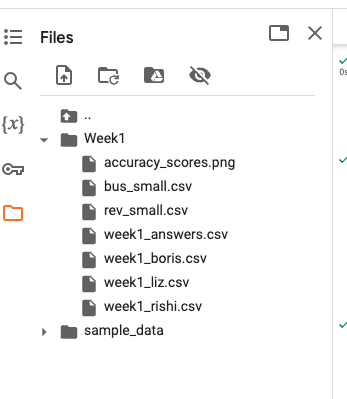

In [ ]:
print(os.getcwd())

# Review data
rev_small = pd.read_csv('rev_small.csv')

# Business data
bus_small = pd.read_csv('bus_small.csv')

# First thing - check variables
print(list(rev_small))
print(list(bus_small))

/content/Week1
['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date', 'user_name', 'user_review_count', 'user_yelping_since', 'user_average_stars', 'user_male', 'word_count', 'male']
['business_id', 'name', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'average_stars', 'review_count', 'categories', 'WiFi', 'BikeParking', 'BusinessParking', 'BusinessAcceptsCreditCards', 'RestaurantsReservations', 'Caters', 'OutdoorSeating', 'RestaurantsGoodForGroups', 'price', 'Ambience', 'HasTV', 'Alcohol', 'GoodForMeal', 'RestaurantsTakeOut', 'NoiseLevel', 'RestaurantsAttire', 'RestaurantsDelivery', 'GoodForKids']


In [ ]:
# We want to use reviews to predict price data, but price is in bus_small, not rev_small

# To move the business data over to the review data, we use pd.merge and left_join

rev_small = pd.merge(rev_small, bus_small, how = 'left', on = 'business_id')

print(list(rev_small))
print(rev_small.head())

['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date', 'user_name', 'user_review_count', 'user_yelping_since', 'user_average_stars', 'user_male', 'word_count', 'male', 'name', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'average_stars', 'review_count', 'categories', 'WiFi', 'BikeParking', 'BusinessParking', 'BusinessAcceptsCreditCards', 'RestaurantsReservations', 'Caters', 'OutdoorSeating', 'RestaurantsGoodForGroups', 'price', 'Ambience', 'HasTV', 'Alcohol', 'GoodForMeal', 'RestaurantsTakeOut', 'NoiseLevel', 'RestaurantsAttire', 'RestaurantsDelivery', 'GoodForKids']
                review_id                 user_id             business_id  \
0  WZ6mS1JNzHkGW5CvOAz9OQ  CkrlmJdNgk-qx0Xrqw1CAQ  YWSsD10TzzqE1htRG9fQKw   
1  FnKWiUl0xdzUf-fle8-nNw  czMZcN-N6po8Ai-RXHVmtg  YWSsD10TzzqE1htRG9fQKw   
2  Inbc-FPBw5POtW-JKPv7Ng  2m9C5FAnf7TqPnsa6mBXOA  CoZmZKv2lCYd-UoAsAUobA   
3  D7ieZWJoXLq9cdCZljq0MQ  XaCTuS3TPl-hPgj194i9EQ  5kegZHJdcscpSfc5AB

In [ ]:
# Calculate a 1-gram feature count matrix for the review data, with no dropped words

dfm1 = TAB_dfm(rev_small['text'], ngrams_range = (0,1), stop_words = False, min_prop = 0)

print(dfm1)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


       a  aahh  aaron  abandon  abat  abbey  abbi  abc  abdomen  abigail  ...  \
0     10     0      0        0     0      0     0    0        0        0  ...   
1      1     0      0        0     0      0     0    0        0        0  ...   
2      1     0      0        0     0      0     0    0        0        0  ...   
3      2     0      0        0     0      0     0    0        0        0  ...   
4      0     0      0        0     0      0     0    0        0        0  ...   
...   ..   ...    ...      ...   ...    ...   ...  ...      ...      ...  ...   
2830   1     0      0        0     0      0     0    0        0        0  ...   
2831   1     0      0        0     0      0     0    0        0        0  ...   
2832   7     0      0        0     0      0     0    0        0        0  ...   
2833   2     0      0        0     0      0     0    0        0        0  ...   
2834   4     0      0        0     0      0     0    0        0        0  ...   

      zing  zippi  ziti  zo

In [ ]:
# Most common words
dfm1.mean().sort_values(ascending = False)[:20]

the     5.562610
and     3.708995
i       3.305467
a       2.921693
to      2.341446
it      1.800353
of      1.625044
was     1.596825
is      1.480071
for     1.265961
in      1.224691
but     1.037743
that    0.998589
you     0.917460
with    0.894180
s       0.880423
they    0.861376
my      0.810582
t       0.806702
this    0.791534
dtype: float64

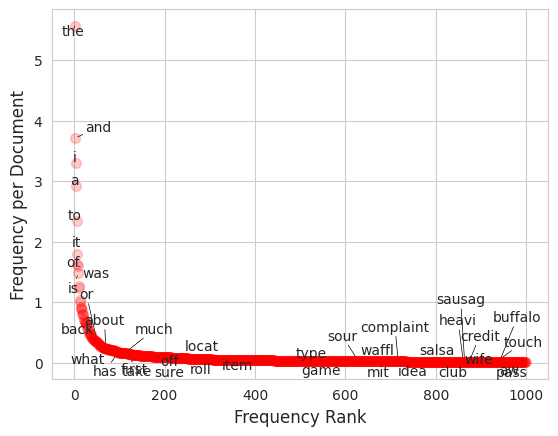

<Figure size 640x480 with 0 Axes>

In [ ]:
# calculate the mean for each column
mean_cols = dfm1.mean()

ngram_counts = np.array([list(dfm1),
                         round(mean_cols,5).tolist(),
                         round(mean_cols.rank(ascending = False, method = 'first'),1).tolist()]).T
columns = ['word', 'frequency', 'f_rank']
ngram_counts = pd.DataFrame(data = ngram_counts, columns = columns)

# converting relevent columns to numeric values
ngram_counts['frequency'] = pd.to_numeric(ngram_counts['frequency'])
ngram_counts['f_rank'] = pd.to_numeric(ngram_counts['f_rank'])

# sort by f_rank
ngram_counts = ngram_counts.sort_values('f_rank', ascending = True)
# print(ngram_counts)
# print(ngram_counts.dtypes)

# select random samples
word_labels = pd.concat([ngram_counts[:9], # top 10 words
                     ngram_counts[10:200].sample(n=10), # ten random words from 11-200
                     ngram_counts[200:1000].sample(n=20), # 20 random words from 200-1000
                     ngram_counts[1000:].sample(n=20)], # 20 random words above 1000
                    ignore_index=False)

# dropping rarest words
ngram_counts = ngram_counts[ngram_counts['f_rank'] < 1000]
word_labels = word_labels[word_labels['f_rank'] < 1000]

# print(ngram_counts)
x = ngram_counts['f_rank']
y = ngram_counts['frequency']
labels = word_labels.index.values.tolist()

sns.set_style("whitegrid") # may need to install seaborn if running on local machine
fig, ax = plt.subplots()

# alpha sets the transparency - helps when you have some overlapping datapoints
ax.plot(x, y, color = 'red',
            linestyle='', marker='o', markersize=7, alpha=0.2)

texts = [ax.text(x[i], y[i], ngram_counts['word'][i],
                #  bbox=dict(facecolor='white', edgecolor='red')
                 ) for i in labels]

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='k', lw=0.5),
            force_static = (0.1,0.5),
            force_text = (0.1,0.5)
            )


plt.xlabel("Frequency Rank", fontsize = 12)
plt.ylabel("Frequency per Document", fontsize = 12)
plt.show()
plt.savefig('word_freq.png')
# still a bit messy but you can play around with the parameters in your own time

In [ ]:
# First, let's look at our price data
print(rev_small['price'].value_counts())

2    1683
1    1152
Name: price, dtype: int64


In [ ]:
# Let's only use 1-grams for now
dfm3 = TAB_dfm(rev_small['text'], ngrams_range = (0,1))

print(dfm3)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'veri', 'whatev'

      abl  abov  absolut  accommod  actual  ad  add  addit  afford  afternoon  \
0       0     0        0         0       0   0    0      0       0          2   
1       0     0        0         0       1   0    0      0       0          0   
2       0     0        0         0       0   0    0      0       0          0   
3       0     0        0         0       1   0    0      0       0          0   
4       0     0        0         0       0   0    0      0       0          0   
...   ...   ...      ...       ...     ...  ..  ...    ...     ...        ...   
2830    0     0        0         0       0   0    0      0       0          0   
2831    0     0        1         0       0   0    0      0       0          0   
2832    0     0        0         0       0   0    0      0       0          0   
2833    0     0        0         0       0   0    0      0       0          0   
2834    0     0        0         0       0   0    0      0       0          0   

      ...  wow  wrap  write

In [ ]:
# What we really care about is - does the presence of a word predict price?
# To correlate all variables with a target variable (price):
print(dfm3.corrwith(dfm3["price"]))

# most negative correlations
print(dfm3.corrwith(dfm3["price"]).sort_values()[:10])

# most positive correlations
print(dfm3.corrwith(dfm3["price"]).sort_values(ascending = False)[:10])

abl         0.027439
abov        0.043138
absolut    -0.024364
accommod    0.029355
actual      0.048874
              ...   
year        0.008593
yelp        0.000752
yes        -0.011473
yum         0.004527
yummi       0.010164
Length: 815, dtype: float64
old       -0.039745
god       -0.039281
complet   -0.032461
charm     -0.031901
subway    -0.031650
cool      -0.030453
apolog    -0.030301
mass      -0.029497
girl      -0.028591
kid       -0.028064
dtype: float64
price      1.000000
reason     0.307317
qualiti    0.176563
portion    0.134573
low        0.132000
food       0.128899
charg      0.123894
high       0.121324
good       0.121118
veri       0.120429
dtype: float64


In [ ]:
# Let's put this on a plot

correlations = round(dfm3.corrwith(dfm3["price"]),3).tolist()
frequency = round(dfm3.mean(),3).tolist()
word = list(dfm3)

cor_set = pd.DataFrame(np.array([pd.to_numeric(correlations),
                                 pd.to_numeric(frequency),
                                 word]).T,
                       columns = ['correlations', 'frequency', 'word'])

# Ensure that numeric fields are indeed numeric
cor_set['correlations'] = pd.to_numeric(cor_set['correlations'])
cor_set['frequency'] = pd.to_numeric(cor_set['frequency'])

print(cor_set.dtypes)

# let's group the points so we can add color

# First, because there are a few conditions, write out all the conditions in order
conditions = [ cor_set['correlations'] > 0.02,
               (cor_set['correlations'] <= 0.02) & (cor_set['correlations'] >= -0.02),
               cor_set['correlations'] < -0.02 ]

# then, create list of classifications
choices = [ "high", 'none', 'low' ]

# Then create new variable cased on conditions and choices
cor_set["colour"] = np.select(conditions, choices, default=np.nan)

# Removing extremes
cor_set = cor_set[(cor_set['word'] != 'price')]

cor_set = cor_set[(cor_set['correlations'] < 0.2) &
                  (cor_set['correlations'] > -0.2)]

# visually check
print(cor_set)

correlations    float64
frequency       float64
word             object
dtype: object
     correlations  frequency      word colour
0           0.027      0.025       abl   high
1           0.043      0.013      abov   high
2          -0.024      0.036   absolut    low
3           0.029      0.012  accommod   high
4           0.049      0.074    actual   high
..            ...        ...       ...    ...
810         0.009      0.066      year   none
811         0.001      0.024      yelp   none
812        -0.011      0.030       yes   none
813         0.005      0.018       yum   none
814         0.010      0.037     yummi   none

[813 rows x 4 columns]


<ipython-input-52-a2004559b97c>:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([.01,.05,.1,.2,.5,1,2,5])


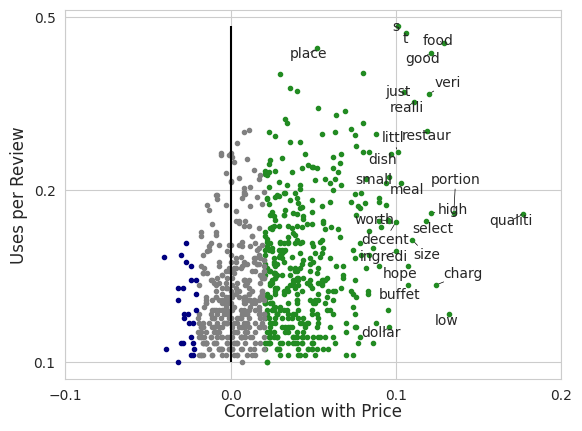

In [ ]:
# lets make a plot
# we going to plot the points first
# then add the labels

sns.set_style("whitegrid") # may need to install seaborn if running on local machine
fig, ax = plt.subplots()

category = ['high', 'none', 'low']
colours = ['forestgreen', 'gray', 'navy']

# plot points
for i in range(len(category)):
  x = cor_set['correlations'][cor_set['colour'] == category[i]]
  y = cor_set['frequency'][cor_set['colour'] == category[i]]

  ax.plot(x, y, color = colours[i],
              linestyle='', marker='o', markersize=3)

# log-transform the Y axis so it's not compressed at the bottom
ax.set_yscale('log')
# manually set axis ticks
ax.set_yticklabels([.01,.05,.1,.2,.5,1,2,5])

# select top correlations/frequency
top_words = cor_set[cor_set['colour'] == 'high']
top_words = top_words[(top_words['correlations'] > 0.095) | (top_words['frequency'] > 0.5)]


# select bottom correlations/frequency
bottom_words = cor_set[cor_set['colour'] == 'low']
bottom_words = bottom_words[(bottom_words['correlations'] < -0.05) |
                            (bottom_words['frequency'] > 0.4)]

all_labels = pd.concat([top_words, bottom_words])
x = all_labels['correlations']
y = all_labels['frequency']
words = all_labels['word']

texts = [ax.text(x[i], y[i], words[i],
                #  bbox=dict(facecolor='white', edgecolor='red')
                 ) for i in all_labels.index.values.tolist()]

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='k', lw=0.5),
            force_static = (0.1,0.5),
            force_text = (0.1,0.5)
            )

ax.vlines(x=0, ymin=min(cor_set['frequency']), ymax=max(cor_set['frequency']), colors='black')

plt.xlim(-0.1, 0.1)
# plt.ylim(min(cor_set['frequency']), max(cor_set['frequency']) + 0.001)

xticks = np.arange(-0.1, 0.3, 0.1)
ax.set_xticks(xticks)

plt.xlabel("Correlation with Price", fontsize = 12, labelpad=0.02)
plt.ylabel("Uses per Review", fontsize = 12)
plt.show()


As we said in class we are not interested in the effects of individual words. Instead, we care more about how all the words perform as a class

In [ ]:
y = rev_small['price'].tolist()
X = dfm3.reset_index(drop = True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# print(X_test)
# print(y)


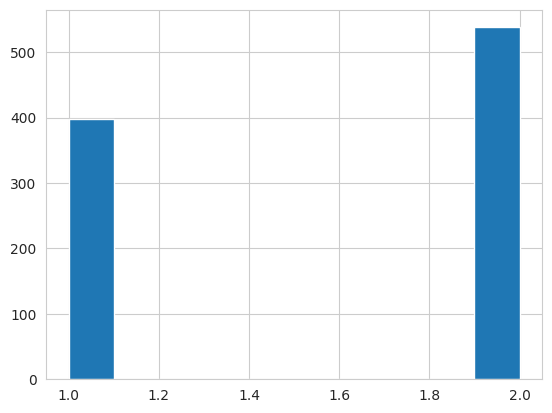

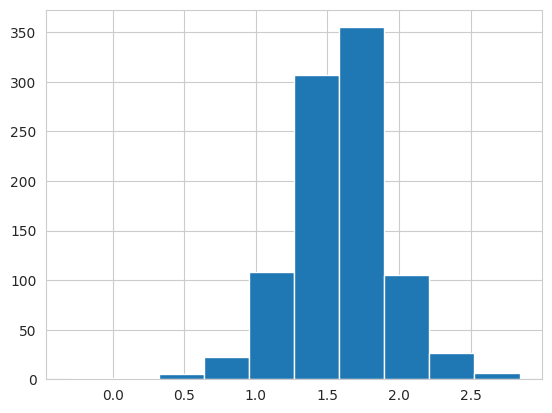

In [ ]:
clf = Lasso(alpha = 0.001)

# generate predictions for test data
clf.fit(X_train, y_train)
test_predict = clf.predict(X_test)

plt.hist(y_test)
plt.show()

plt.hist(test_predict)
plt.show()

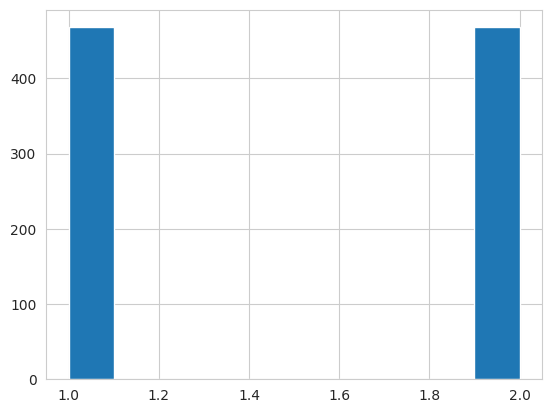

In [ ]:
# For now, let's just split the predictions in two, using the median

test_predict_binary= np.where(test_predict > np.median(test_predict), 2, 1)

# This should have the same values as testY
plt.hist(test_predict_binary)
plt.show()

In [ ]:
# and we can calculate accuracy from that

round(100*np.mean(test_predict_binary==y_test),3)

74.786